<a href="https://colab.research.google.com/github/puskat-debug/database-assign.ipynb/blob/main/Database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pymongo dnspython --quiet

%load_ext rpy2.ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 26.8 MB/s eta 0:00:00


In [4]:
%%R
install.packages(c("sqldf", "dplyr", "lubridate", "ggplot2", "corrplot", "tidyr"),
                 repos = "https://cran.r-project.org", quiet = TRUE)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’



In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
path = "/content/drive/MyDrive/Database Assignment/"

In [8]:
import os
os.listdir(path)

['Database',
 'vehicles.csv',
 'data_dictionary.csv',
 'incidents.csv',
 'customers.csv',
 'app_events.csv',
 'deliveries.csv',
 'README.txt',
 'orders.csv',
 'hubs.csv',
 'complaints.csv',
 'drivers.csv',
 'northstar_data_dictionary.csv',
 'northstar_cleaned_app_events.csv']

In [9]:
%%R
library(sqldf)
library(dplyr)
library(ggplot2)
library(corrplot)
library(tidyr)

path <- "/content/drive/MyDrive/Database Assignment/"

deliveries <- read.csv(paste0(path, "deliveries.csv"),  stringsAsFactors = FALSE)
orders     <- read.csv(paste0(path, "orders.csv"),       stringsAsFactors = FALSE)
customers  <- read.csv(paste0(path, "customers.csv"),    stringsAsFactors = FALSE)
complaints <- read.csv(paste0(path, "complaints.csv"),   stringsAsFactors = FALSE)
incidents  <- read.csv(paste0(path, "incidents.csv"),    stringsAsFactors = FALSE)
drivers    <- read.csv(paste0(path, "drivers.csv"),      stringsAsFactors = FALSE)
vehicles   <- read.csv(paste0(path, "vehicles.csv"),     stringsAsFactors = FALSE)
app_events <- read.csv(paste0(path, "app_events.csv"),   stringsAsFactors = FALSE)

cat("Files loaded:\n")
cat("  deliveries:", nrow(deliveries), "\n")
cat("  orders:    ", nrow(orders),     "\n")
cat("  customers: ", nrow(customers),  "\n")
cat("  complaints:", nrow(complaints), "\n")
cat("  incidents: ", nrow(incidents),  "\n")
cat("  drivers:   ", nrow(drivers),    "\n")
cat("  vehicles:  ", nrow(vehicles),   "\n")
cat("  app_events:", nrow(app_events), "\n")

Files loaded:
  deliveries: 950 
  orders:     1250 
  customers:  650 
  complaints: 320 
  incidents:  280 
  drivers:    170 
  vehicles:   120 
  app_events: 640 


Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

corrplot 0.95 loaded
In addition: Warning message:
no DISPLAY variable so Tk is not available 


In [12]:
%%R
for (name in c("deliveries","orders","customers","complaints",
               "incidents","drivers","vehicles","app_events")) {
  df <- get(name)
  cat("\n==============================\n")
  cat(name, ":", nrow(df), "rows,", ncol(df), "cols\n")
  cat("Columns:", paste(colnames(df), collapse=", "), "\n")
  missing <- colSums(is.na(df))
  if (any(missing > 0)) {
    cat("Missing values:\n")
    print(missing[missing > 0])
  } else {
    cat("No missing values\n")
  }
}


deliveries : 950 rows, 13 cols
Columns: delivery_id, order_id, driver_id, vehicle_id, hub_id, dispatch_time, delivery_completed_at, delivery_status, route_distance_km, manual_route_override_count, proof_of_completion_missing, customer_rating_post_delivery, fuel_or_charge_cost 
Missing values:
customer_rating_post_delivery 
                           14 

orders : 1250 rows, 11 cols
Columns: order_id, customer_id, service_type, order_created_at, promised_window_hours, pickup_zone, dropoff_zone, priority_level, order_value, booking_channel, special_handling_flag 
No missing values

customers : 650 rows, 9 cols
Columns: customer_id, age, home_zone, customer_type, signup_date, loyalty_score, app_engagement_score, preferred_channel, account_status 
Missing values:
loyalty_score 
           20 

complaints : 320 rows, 10 cols
Columns: complaint_id, customer_id, order_id, complaint_type, channel, severity, created_at, status, resolution_days, compensation_amount 
Missing values:
compensation

In [14]:
%%R
deliveries <- deliveries[!duplicated(deliveries), ]
orders     <- orders[!duplicated(orders), ]
customers  <- customers[!duplicated(customers), ]
complaints <- complaints[!duplicated(complaints), ]
incidents  <- incidents[!duplicated(incidents), ]
drivers    <- drivers[!duplicated(drivers), ]
vehicles   <- vehicles[!duplicated(vehicles), ]
app_events <- app_events[!duplicated(app_events), ]

cat("Duplicates removed. Row counts:\n")
cat("  deliveries:", nrow(deliveries), "\n")
cat("  orders:    ", nrow(orders),     "\n")

Duplicates removed. Row counts:
  deliveries: 950 
  orders:     1250 


In [15]:
%%R
zone_map <- c(
  "ctr"="Central",   "CENTRAL"="Central",   "central"="Central",
  "NORTH"="North",   "north"="North",
  "SOUTH"="South",   "south"="South",
  "EAST"="East",     "east"="East",
  "WEST"="West",     "west"="West",
  "RiverSide"="Riverside", "RIVERSIDE"="Riverside", "riverside"="Riverside",
  "AIRPORT"="Airport",     "airport"="Airport"
)
normalise_zone <- function(x) {
  x <- trimws(x)
  ifelse(x %in% names(zone_map), zone_map[x], x)
}

orders$pickup_zone     <- normalise_zone(orders$pickup_zone)
orders$dropoff_zone    <- normalise_zone(orders$dropoff_zone)
drivers$base_zone      <- normalise_zone(drivers$base_zone)
vehicles$assigned_zone <- normalise_zone(vehicles$assigned_zone)

cat("Zones after normalisation:\n")
print(unique(orders$pickup_zone))

Zones after normalisation:
[1] "Airport"   "North"     "West"      "Riverside" "Central"   "South"    
[7] "East"      "Ctr"      


In [17]:
%%R
zone_perf <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(*)                                                        AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed')
          THEN 1 ELSE 0 END) / COUNT(*), 2)                        AS failure_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_pct DESC
")
print(zone_perf)

  pickup_zone total_deliveries failed delayed failure_pct avg_cost avg_rating
1         Ctr               64     11      24       54.69    12.07       3.43
2     Central              110     22      27       44.55    12.15       3.62
3     Airport              113     12      31       38.05    17.08       3.98
4   Riverside              119     18      25       36.13    12.39       3.86
5        East              156     19      31       32.05    12.57       3.91
6       North              135     22      21       31.85    12.07       3.90
7        West              114     14      21       30.70    11.94       3.90
8       South              139     14      22       25.90    12.48       4.05


In [19]:
%%R
driver_risk <- sqldf("
  SELECT
    d.driver_id,
    d.base_zone,
    d.employment_type,
    ROUND(AVG(dl.manual_route_override_count), 2) AS avg_overrides,
    COUNT(dl.delivery_id)                          AS total_deliveries,
    SUM(CASE WHEN dl.delivery_status = 'Failed'
        THEN 1 ELSE 0 END)                         AS failures,
    COUNT(i.incident_id)                           AS incidents
  FROM drivers d
  JOIN deliveries dl ON d.driver_id = dl.driver_id
  LEFT JOIN incidents i ON dl.delivery_id = i.delivery_id
  GROUP BY d.driver_id, d.base_zone, d.employment_type
  HAVING avg_overrides >= 2
  ORDER BY avg_overrides DESC
  LIMIT 10
")
print(driver_risk)

   driver_id base_zone employment_type avg_overrides total_deliveries failures
1       D112      East        FullTime          4.50                2        0
2       D127   Central        FullTime          2.83                6        0
3       D021     South        FullTime          2.50                2        0
4       D051      West        FullTime          2.00                2        2
5       D060     South        FullTime          2.00                2        0
6       D062     South        FullTime          2.00                3        1
7       D069     North        PartTime          2.00                8        1
8       D079     South        PartTime          2.00                2        0
9       D085     North        PartTime          2.00                4        0
10      D105 Riverside        Contract          2.00                7        1
   incidents
1          2
2          1
3          1
4          0
5          1
6          0
7          4
8          0
9          0
1

In [20]:
%%R
complaint_svc <- sqldf("
  SELECT
    o.service_type,
    COUNT(c.complaint_id)                AS complaints,
    ROUND(AVG(c.resolution_days), 2)     AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,
    SUM(CASE WHEN c.severity = 'High'
        THEN 1 ELSE 0 END)               AS high_severity
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY complaints DESC
")
print(complaint_svc)

  service_type complaints avg_resolution_days avg_compensation high_severity
1    Passenger         84                7.74            20.72            22
2       Retail         83                7.89            19.05            13
3       Parcel         77                8.34            20.61            22
4     Business         39                7.95            20.79             9
5      Medical         37                7.57            20.56            11


In [21]:
%%R
vehicle_impact <- sqldf("
  SELECT
    v.maintenance_status,
    COUNT(dl.delivery_id)                                           AS deliveries,
    SUM(CASE WHEN dl.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    ROUND(100.0 * SUM(CASE WHEN dl.delivery_status = 'Failed'
          THEN 1 ELSE 0 END) / COUNT(dl.delivery_id), 2)           AS fail_pct,
    ROUND(AVG(v.battery_health_pct), 2)                             AS avg_battery_pct
  FROM vehicles v
  JOIN deliveries dl ON v.vehicle_id = dl.vehicle_id
  GROUP BY v.maintenance_status
  ORDER BY fail_pct DESC
")
print(vehicle_impact)

  maintenance_status deliveries failed fail_pct avg_battery_pct
1           InRepair        254     77    30.31           76.73
2             Active        542     45     8.30           76.56
3          Scheduled        154     10     6.49           78.74


  delivery_status   n  pct
1         Delayed 202 21.3
2          Failed 132 13.9
3          OnTime 616 64.8


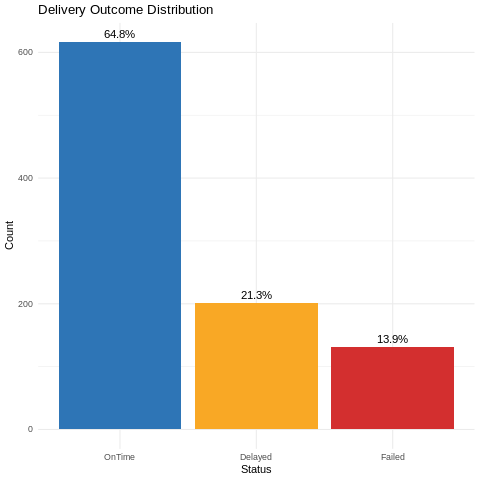

In [22]:
%%R
status_counts <- deliveries %>%
  count(delivery_status) %>%
  mutate(pct = round(n / sum(n) * 100, 1))
print(status_counts)

ggplot(status_counts, aes(x = reorder(delivery_status, -n), y = n, fill = delivery_status)) +
  geom_col() +
  geom_text(aes(label = paste0(pct, "%")), vjust = -0.5, size = 4) +
  scale_fill_manual(values = c("OnTime"="#2E75B6", "Delayed"="#F9A825", "Failed"="#D32F2F")) +
  labs(title = "Delivery Outcome Distribution", x = "Status", y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")

In [23]:
%%R
zone_status_tbl <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  count(pickup_zone, delivery_status) %>%
  pivot_wider(names_from = delivery_status, values_from = n, values_fill = 0)

chi_test <- chisq.test(as.matrix(zone_status_tbl[, -1]))
print(chi_test)


	Pearson's Chi-squared test

data:  as.matrix(zone_status_tbl[, -1])
X-squared = 30.183, df = 14, p-value = 0.007201



                              manual_route_override_count fuel_or_charge_cost
manual_route_override_count                         1.000               0.099
fuel_or_charge_cost                                 0.099               1.000
customer_rating_post_delivery                      -0.060              -0.059
proof_of_completion_missing                         0.041               0.057
                              customer_rating_post_delivery
manual_route_override_count                          -0.060
fuel_or_charge_cost                                  -0.059
customer_rating_post_delivery                         1.000
proof_of_completion_missing                          -0.218
                              proof_of_completion_missing
manual_route_override_count                         0.041
fuel_or_charge_cost                                 0.057
customer_rating_post_delivery                      -0.218
proof_of_completion_missing                         1.000


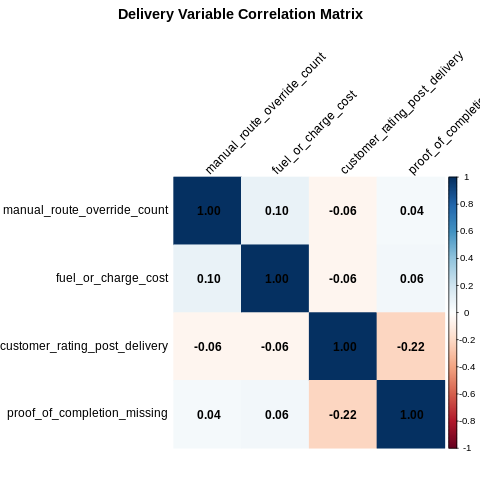

In [24]:
%%R
num_vars <- deliveries %>%
  select(manual_route_override_count, fuel_or_charge_cost,
         customer_rating_post_delivery, proof_of_completion_missing)

cor_mat <- cor(num_vars, use = "complete.obs")
print(round(cor_mat, 3))

corrplot(cor_mat, method = "color", addCoef.col = "black",
         tl.col = "black", tl.srt = 45,
         title = "Delivery Variable Correlation Matrix", mar = c(0,0,2,0))

# A tibble: 3 × 5
  employment_type total fail_rate avg_override avg_rating
  <chr>           <int>     <dbl>        <dbl>      <dbl>
1 Contract          126      14.3         0.93       3.83
2 FullTime          582      14.6         1.02       3.87
3 PartTime          242      12           0.86       3.88



(`stat_boxplot()`). 



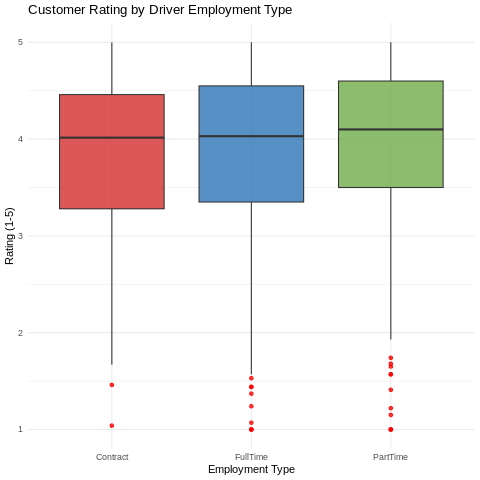

In [25]:
%%R
driver_summary <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  group_by(employment_type) %>%
  summarise(
    total        = n(),
    fail_rate    = round(mean(delivery_status == "Failed") * 100, 1),
    avg_override = round(mean(manual_route_override_count), 2),
    avg_rating   = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    .groups = "drop"
  )
print(driver_summary)

ggplot(
  deliveries %>% left_join(drivers, by = "driver_id"),
  aes(x = employment_type, y = customer_rating_post_delivery, fill = employment_type)
) +
  geom_boxplot(alpha = 0.8, outlier.colour = "red") +
  scale_fill_manual(values = c("FullTime"="#2E75B6", "PartTime"="#70AD47", "Contract"="#D32F2F")) +
  labs(title = "Customer Rating by Driver Employment Type",
       x = "Employment Type", y = "Rating (1-5)") +
  theme_minimal() +
  theme(legend.position = "none")

In [26]:
%%R
segment_complaints <- complaints %>%
  left_join(customers, by = "customer_id") %>%
  group_by(customer_type) %>%
  summarise(
    complaints       = n(),
    avg_resolution   = round(mean(resolution_days,     na.rm = TRUE), 2),
    avg_compensation = round(mean(compensation_amount, na.rm = TRUE), 2),
    .groups = "drop"
  )
print(segment_complaints)

# A tibble: 3 × 4
  customer_type complaints avg_resolution avg_compensation
  <chr>              <int>          <dbl>            <dbl>
1 Consumer             242           7.86             20.6
2 Enterprise            28           8.39             20.2
3 SME                   50           8.02             18.5


# A tibble: 8 × 4
  event_type                  total failed fail_pct
  <chr>                       <int>  <int>    <dbl>
1 chat_escalated                 38     19     50  
2 payment_retry                  69     19     27.5
3 cancel_attempt                 28      0      0  
4 chat_opened                    88      0      0  
5 delivery_instruction_update    75      0      0  
6 eta_refresh                   105      0      0  
7 search_route                   99      0      0  
8 track_order                   138      0      0  


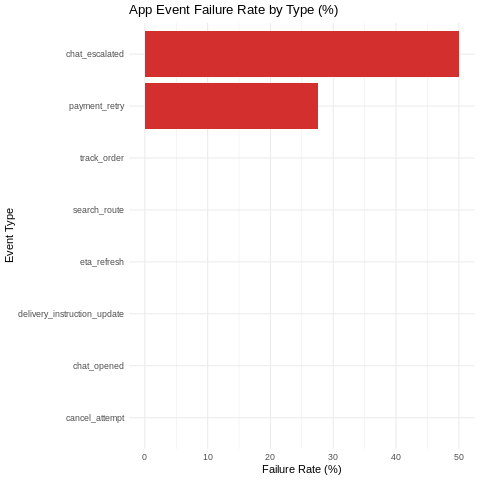

In [27]:
%%R
event_fail <- app_events %>%
  group_by(event_type) %>%
  summarise(
    total    = n(),
    failed   = sum(success_flag == 0),
    fail_pct = round(100 * failed / total, 1),
    .groups  = "drop"
  ) %>%
  arrange(desc(fail_pct))
print(event_fail)

ggplot(event_fail, aes(x = reorder(event_type, fail_pct), y = fail_pct, fill = fail_pct > 20)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c("FALSE"="#2E75B6", "TRUE"="#D32F2F")) +
  labs(title = "App Event Failure Rate by Type (%)", x = "Event Type", y = "Failure Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")